In [1]:
import pyart
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import MultipleLocator
import numpy as np
import sys
import glob
sys.path.append('/home/robbyfrost/Analysis/TurbTor_Radar/')
from functions import get_time_pyart

# plotting set up
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=15)
rc('figure', facecolor='white')


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
# path to nexrad files
drad = "/data/arrcwx/robbyfrost/nexrad/klbb/"
# list of files
rfiles = sorted(glob.glob(f"{drad}*"))

# desired sweep index
swp = 0

# list to hold sweeps
rall = []
for f in rfiles:
    # read volume
    radar = pyart.io.read(f)
    # remove survey mode sweeps
    ns = np.unique(radar.fixed_angle['data'], return_index=True)[1]
    for i in range(len(ns)-1):
        if (ns[i+1]-ns[i])//2:
            ns[i] = ns[i] + 1
    radar = radar.extract_sweeps(ns)
    # append to list
    rall.append(radar.extract_sweeps([swp]))

In [3]:
def latlon_to_xy_km(ref_lat, ref_lon, lat, lon):
    R = 6371.0  # Earth radius in km
    dlat = np.deg2rad(lat - ref_lat)
    dlon = np.deg2rad(lon - ref_lon)
    x = R * dlon * np.cos(np.deg2rad(ref_lat))
    y = R * dlat
    return x, y

rlat, rlon = float(rall[0].latitude['data']), float(rall[0].longitude['data'][0])
hlat, hlon = 33.92629, -102.537

hx, hy = latlon_to_xy_km(rlat, rlon, hlat, hlon)

In [ ]:
fig, axs = plt.subplots(
    figsize=(23.5,15),
    ncols=3,
    nrows=2,
    sharex=True,
    sharey=True,
    constrained_layout=True,
    dpi=200
)

for jt in range(1,4,1):
    cidx = jt-1
    # radar data
    radswp = rall[jt]
    yr, mo, da, hr, mi, se, tstring, tdt = get_time_pyart(radswp.time)
    x, y, z = radswp.get_gate_x_y_z(swp)
    el = radar.fixed_angle['data'][swp]
    ref = radswp.fields['reflectivity']['data']
    vel = radswp.fields['velocity']['data']
    # reflectivity
    ax = axs[0,cidx]
    zmin, zmax = 0, 70
    ref_plot = np.ma.masked_less(ref, zmin)
    ax.set_title(f"{tdt.time()} UTC", fontweight='bold', fontsize=25)
    pcmz = ax.pcolormesh(
        x/1e3,
        y/1e3,
        ref_plot,
        vmin=zmin,
        vmax=zmax,
        cmap='Carbone42'
        )
    # radial velocity
    ax = axs[1,cidx]
    vmin, vmax = -50, 50
    pcmv = ax.pcolormesh(
        x/1e3,
        y/1e3,
        vel,
        vmin=vmin,
        vmax=vmax,
        cmap='Carbone42'
        )

# colorbars
cbar = fig.colorbar(pcmz, ax=axs[0,:], pad=0.015, label="$Z$ [dBZ]", orientation='vertical')
cbar.set_ticks(np.arange(zmin, zmax+0.1, 10))
cbar = fig.colorbar(pcmv, ax=axs[1,:], pad=0.015, label="$V_r$ [m s$^{-1}$]", orientation='vertical')
cbar.set_ticks(np.arange(vmin, vmax+0.1, 10))

# clean up plot
labs = "abcdef"
for i, ax in enumerate(axs.flatten()):
    ax.text(
        x=-92.5, 
        y=67.5, 
        s=f"({labs[i]})", 
        ha='center', 
        va='center', 
        fontweight='bold',
        fontsize=20
        )
    ax.set_aspect('equal')
    ax.set_xlim(-95,-45)
    ax.set_ylim(20,70)
    ax.grid(alpha=0.6)
    ax.scatter(hx, hy, c='black', s=2000, marker='*')
for ax in axs[1,:]:
    ax.set_xlabel("Zonal Distance [km]")
for ax in axs[:,0]:
    ax.set_ylabel("Meridional Distance [km]")

In [50]:
import xarray as xr
import os
import pandas as pd
from datetime import datetime, timedelta
sys.path.append('/home/robbyfrost/Analysis/TurbTor_Lidar/')
from lidar_functions import *

def add_scan_time(ds):
    times = ds["time"].values.astype("int64")
    scan_time = np.median(times).astype("datetime64[ns]")
    ds = ds.expand_dims(volume=[scan_time])
    return ds

# lidar directory
dlid = "/data/arrcwx/robbyfrost/halo/20250425/cfrada/"
# lidar files
lfiles = sorted(glob.glob(f"{dlid}*"))
# read all lidar files
lid = [xr.open_dataset(f) for f in lfiles]
# lid = xr.open_mfdataset(
#     lfiles,
#     concat_dim="volume",
#     combine="nested",
#     preprocess=add_scan_time,
#     data_vars="all",
#     coords="all",
#     compat="override",
# )
# array of median sweep times
ltdt = np.empty(len(lid), dtype="datetime64[ns]")
for jt, l in enumerate(lid):
    times = l["time"].values.astype("int64")
    ltdt[jt] = np.median(times).astype("datetime64[ns]")
# ltdt = lid.volume.values

# radar time info
rtdt = []
for radswp in rall:
    yr, mo, da, hr, mi, se, tstring, tdt = get_time_pyart(radswp.time)
    rtdt.append(tdt)
rtdt = np.array(rtdt, dtype='datetime64[s]')

# find index of closest rtdt for each ltdt
rt_idx = []
for lt in ltdt:
    diffs = np.abs(rtdt - lt)
    rt_idx.append(int(np.argmin(diffs)))

# find index of closest ltdt for each rtdt
lt_idx = []
for rt in rtdt:
    diffs = np.abs(rt - ltdt)
    lt_idx.append(int(np.argmin(diffs)))

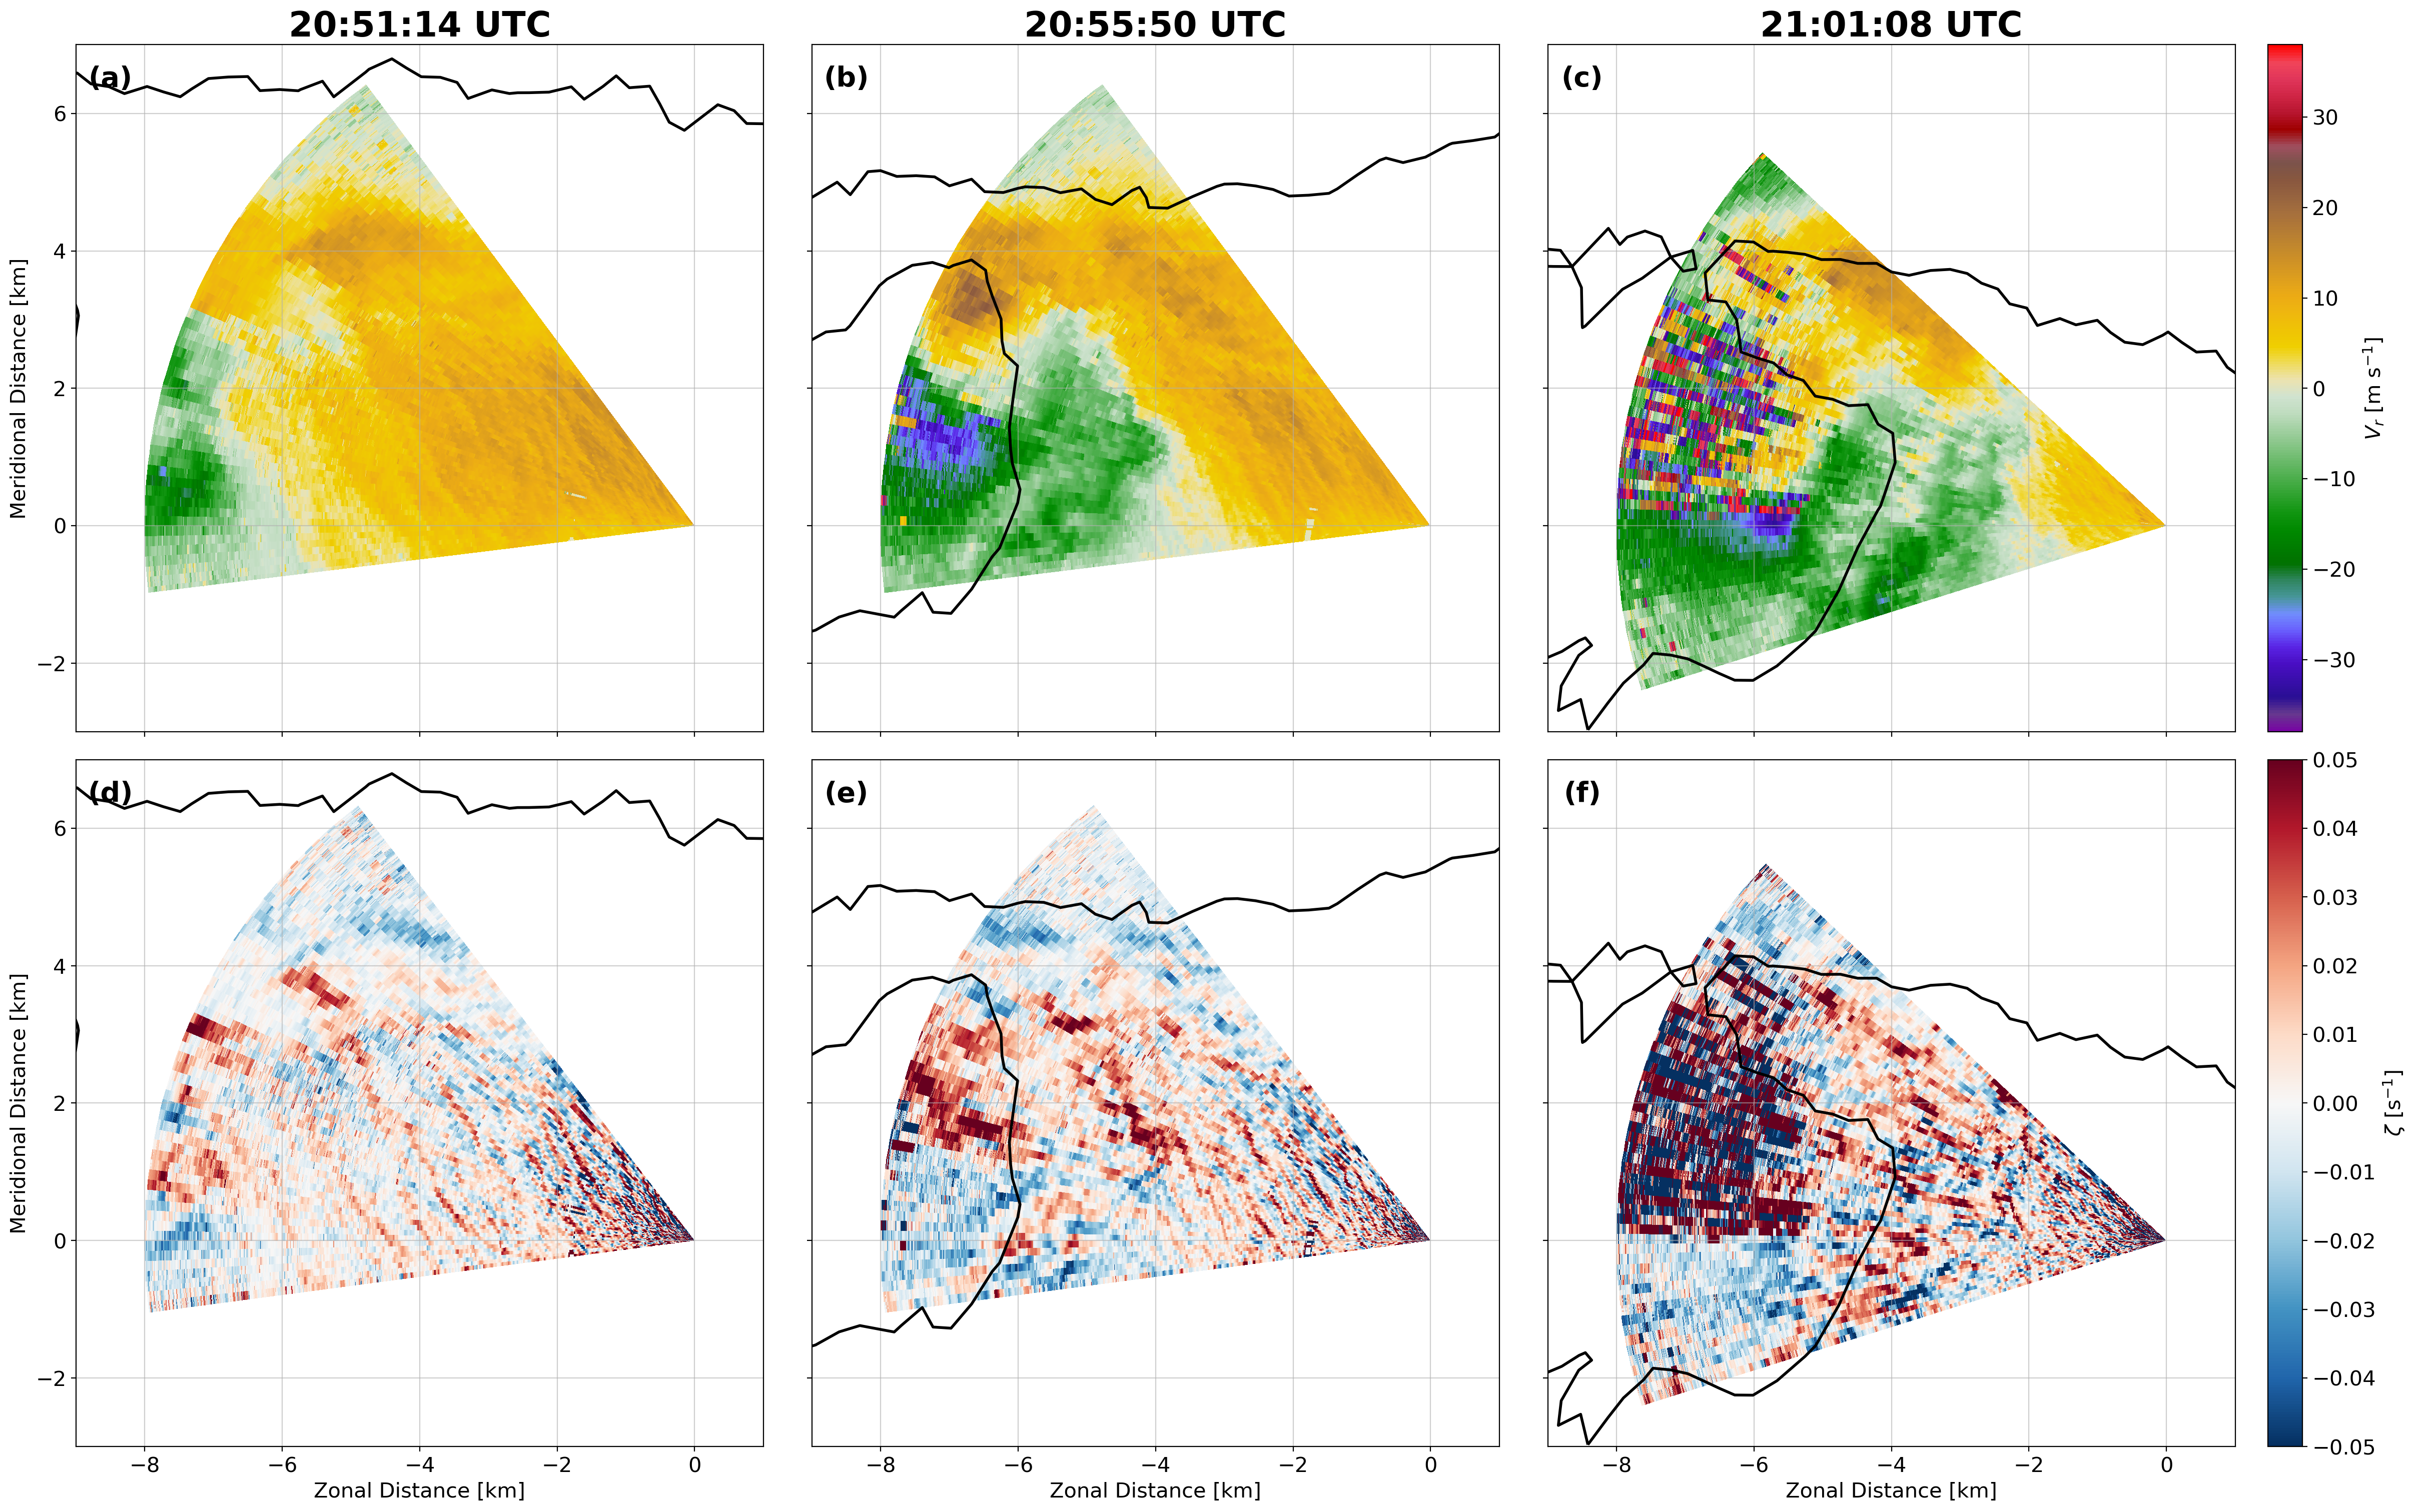

In [60]:
fig, axs = plt.subplots(
    figsize=(24,15),
    ncols=3,
    nrows=2,
    sharex=True,
    sharey=True,
    constrained_layout=True,
    dpi=200
)

for jt in range(1,4,1):
    cidx = jt-1
    # radar time index
    rt = rtdt[jt]
    # lidar time index
    lt = lt_idx[jt]

    # truncate lidar sweep
    l = lid[lt]
    # convert time to python datetime
    ldt = pd.Timestamp(ltdt[lt]).to_pydatetime()
    ldt = ldt.replace(microsecond=0)
    # arrays
    r = l.range.values * 1e3
    az = l.azimuth.values
    vr = l.vr.values
    el = l.elevation.values
    # calculate vorticity
    vort = ((vr[2:,:]-vr[:-2,:]) / ((np.deg2rad(az[2:])-np.deg2rad(az[:-2]))[:,None])) / (r[None,:])
    # lidar cartesian grid points
    lx, ly = dis_angle_to_2Dxy(
        beam_range_2D(r/1e3, el)[0][:,0] * 1e3,
        north0_to_arctheta(az)
        )

    # radar data
    radswp = rall[jt]
    yr, mo, da, hr, mi, se, tstring, tdt = get_time_pyart(radswp.time)
    rx, ry, _ = radswp.get_gate_x_y_z(swp)
    rx, ry = rx-hx*1e3, ry-hy*1e3
    el = radar.fixed_angle['data'][swp]
    ref = radswp.fields['reflectivity']['data']
    vel = radswp.fields['velocity']['data']
        
    # shade velocity
    ax = axs[0,cidx]
    ax.set_title(f"{ldt.time()} UTC", fontsize=25, fontweight='bold')
    vmin, vmax = -38, 38
    pcmv = ax.pcolormesh(
        lx.T/1e3,
        ly.T/1e3,
        vr,
        vmin=vmin,
        vmax=vmax,
        cmap='Carbone42'
    )
    # shade vorticity
    ax = axs[1,cidx]
    zmin, zmax = -0.05, 0.05
    pcmz = ax.pcolormesh(
        lx.T[1:-1,:]/1e3,
        ly.T[1:-1,:]/1e3,
        vort,
        vmin=zmin,
        vmax=zmax,
        cmap='RdBu_r'
    )

    # contour reflectivity
    for ax in axs[:,cidx]:
        ax.contour(
            rx/1e3,
            ry/1e3,
            ref,
            levels=[20],
            linewidths=2,
            colors='black'
        )


# colorbars
cbar = fig.colorbar(pcmv, ax=axs[0,:], pad=0.015, label="$V_r$ [m s$^{-1}$]", orientation='vertical')
cbar.set_ticks(np.arange(-30, 30.01, 10))
cbar = fig.colorbar(pcmz, ax=axs[1,:], pad=0.015, label="$\\zeta$ [s$^{-1}$]", orientation='vertical')
cbar.set_ticks(np.arange(zmin, zmax+1e-5, 0.01))

# clean up plot
labs = "abcdef"
for i, ax in enumerate(axs.flatten()):
    ax.text(
        x=-8.5, 
        y=6.5, 
        s=f"({labs[i]})", 
        ha='center', 
        va='center', 
        fontweight='bold',
        fontsize=20
        )
    ax.set_aspect('equal')
    ax.set_xlim(-9,1)
    ax.set_ylim(-3,7)
    ax.grid(alpha=0.6)
for ax in axs[1,:]:
    ax.set_xlabel("Zonal Distance [km]")
for ax in axs[:,0]:
    ax.set_ylabel("Meridional Distance [km]")